In [2]:
import pandas as pd
import numpy as np

In [3]:
# Load all files
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

In [4]:
# Check missing values
print(orders.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [5]:
# Fix date columns
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])


In [6]:
# Remove cancelled/unavailable orders — only keep delivered
orders = orders[orders['order_status'] == 'delivered']

In [15]:
# Merge everything into one master dataframe
df = orders.merge(items, on='order_id') \
           .merge(products, on='product_id') \
           .merge(customers, on='customer_id') \
           .merge(payments, on='order_id') \
           .merge(reviews, on='order_id', how='left') \
           .merge(category_translation, on='product_category_name', how='left')

In [16]:
# Drop duplicates
df.drop_duplicates(inplace=True)
print("Master df shape:", df.shape)

Master df shape: (115720, 37)


In [17]:
#Q1 — Which category has highest revenue?
category_revenue = df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False)
print(category_revenue.head(10))

product_category_name_english
bed_bath_table           1723932.14
health_beauty            1625923.50
computers_accessories    1563315.62
furniture_decor          1408110.04
watches_gifts            1388699.25
sports_leisure           1357249.46
housewares               1072820.85
auto                      835782.91
garden_tools              813055.77
cool_stuff                746763.39
Name: payment_value, dtype: float64


In [18]:
#Q2 — Which month had peak sales?
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = df.groupby('month')['payment_value'].sum()
print(monthly_sales.sort_values(ascending=False).head(5))

month
2017-11    1559739.87
2018-05    1481529.96
2018-04    1469136.33
2018-03    1441973.39
2018-01    1383865.26
Freq: M, Name: payment_value, dtype: float64


In [19]:
#Q3 — Which region performs best?
region_sales = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)
print(region_sales.head(10))

customer_state
SP    7456516.62
RJ    2699623.08
MG    2290457.39
RS    1118444.44
PR    1036003.69
BA     775836.28
SC     769234.50
GO     497367.84
DF     424872.44
ES     399308.36
Name: payment_value, dtype: float64


In [20]:
#Q4 — Average order value trend?
avg_order = df.groupby('month')['payment_value'].mean()
print(avg_order)

month
2016-10    186.185090
2016-12     19.620000
2017-01    181.735066
2017-02    166.208241
2017-03    164.224480
2017-04    168.342656
2017-05    164.123236
2017-06    158.364341
2017-07    151.005383
2017-08    166.557877
2017-09    199.072633
2017-10    184.176904
2017-11    175.429071
2017-12    158.205990
2018-01    164.393592
2018-02    164.768610
2018-03    171.991101
2018-04    180.861299
2018-05    182.611853
2018-06    175.641254
2018-07    181.358422
2018-08    164.674387
Freq: M, Name: payment_value, dtype: float64


In [21]:
#Q5 — Customer review score distribution?
print(df['review_score'].value_counts().sort_index())

review_score
1.0    13115
2.0     3899
3.0     9649
4.0    22150
5.0    66046
Name: count, dtype: int64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

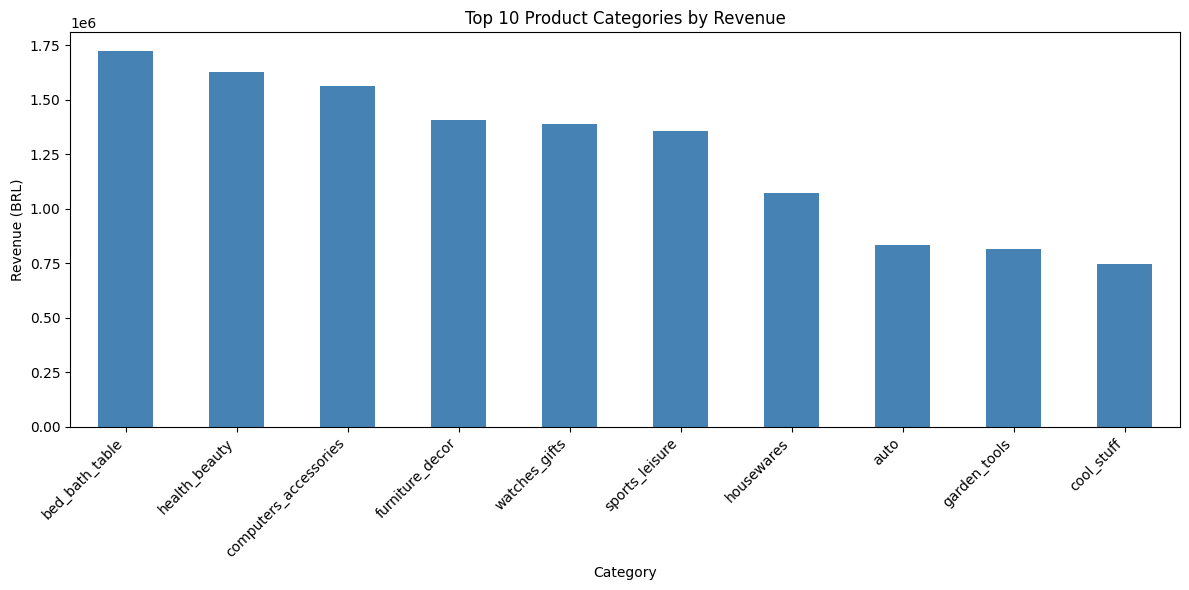

In [23]:
# Chart 1 — Bar: Revenue by Category (top 10)
plt.figure(figsize=(12,6))
category_revenue.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_category_revenue.png')
plt.show()

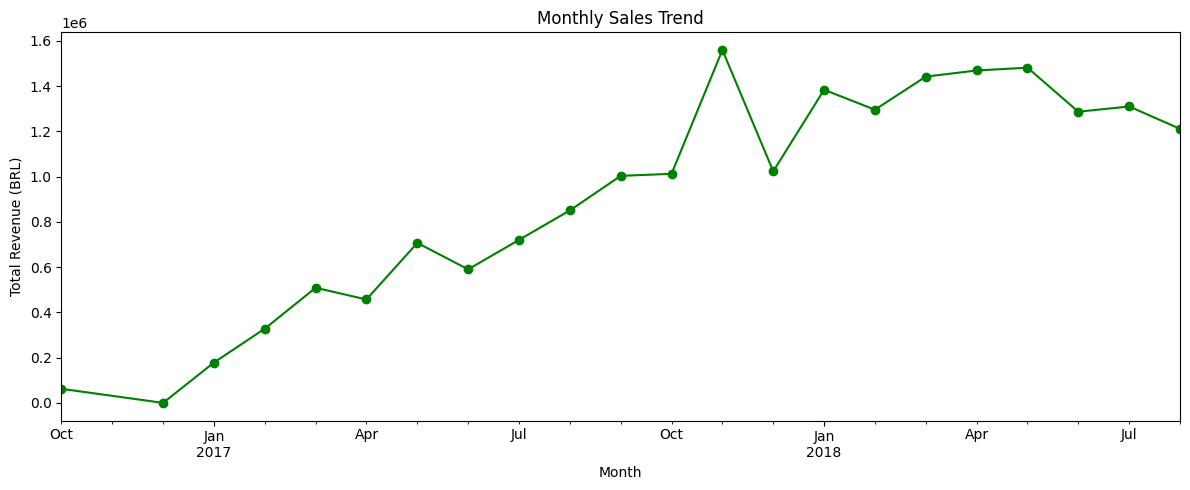

In [24]:
# Chart 2 — Line: Monthly Sales Trend
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png')
plt.show()

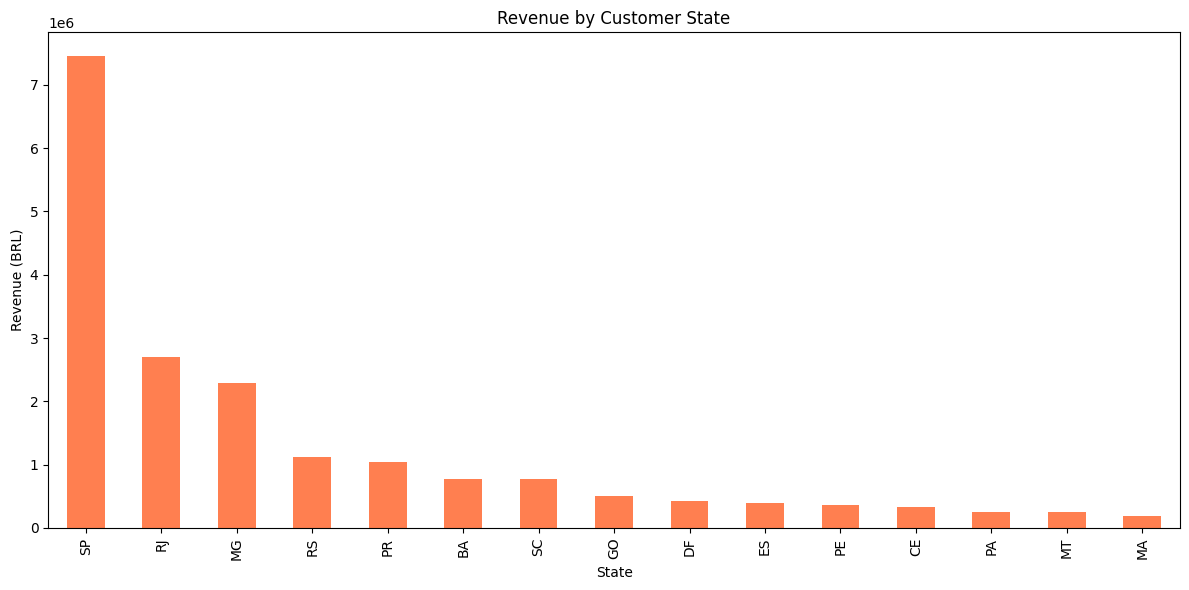

In [25]:
# Chart 3 — Bar: Regional Sales (by state)
plt.figure(figsize=(12,6))
region_sales.head(15).plot(kind='bar', color='coral')
plt.title('Revenue by Customer State')
plt.xlabel('State')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('chart3_regional_sales.png')
plt.show()

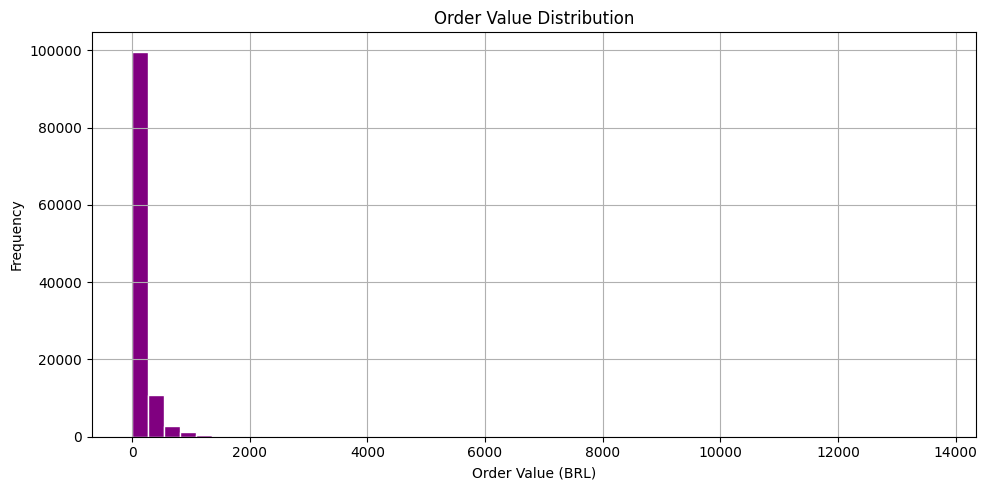

In [26]:
# Chart 4 — Histogram: Order Value Distribution
plt.figure(figsize=(10,5))
df['payment_value'].hist(bins=50, color='purple', edgecolor='white')
plt.title('Order Value Distribution')
plt.xlabel('Order Value (BRL)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart4_order_histogram.png')
plt.show()

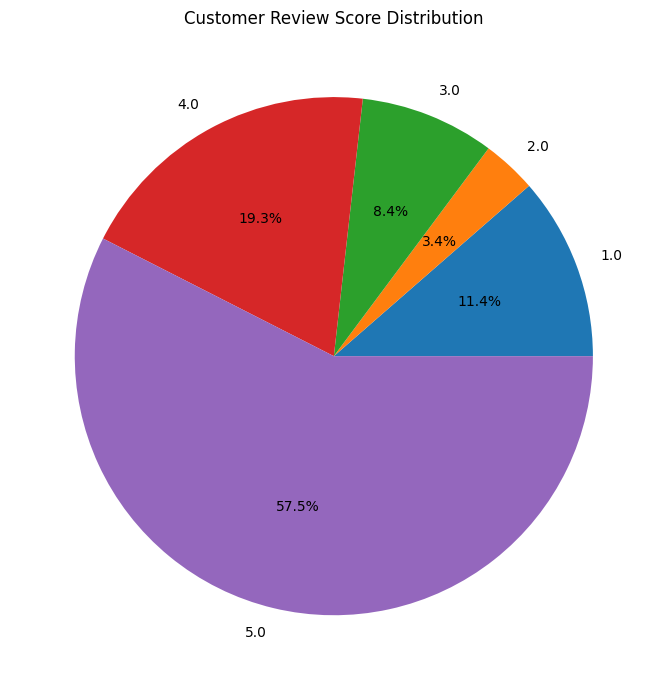

In [27]:
# Chart 5 — Pie: Review Score Distribution
plt.figure(figsize=(7,7))
df['review_score'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title('Customer Review Score Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart5_review_pie.png')
plt.show()

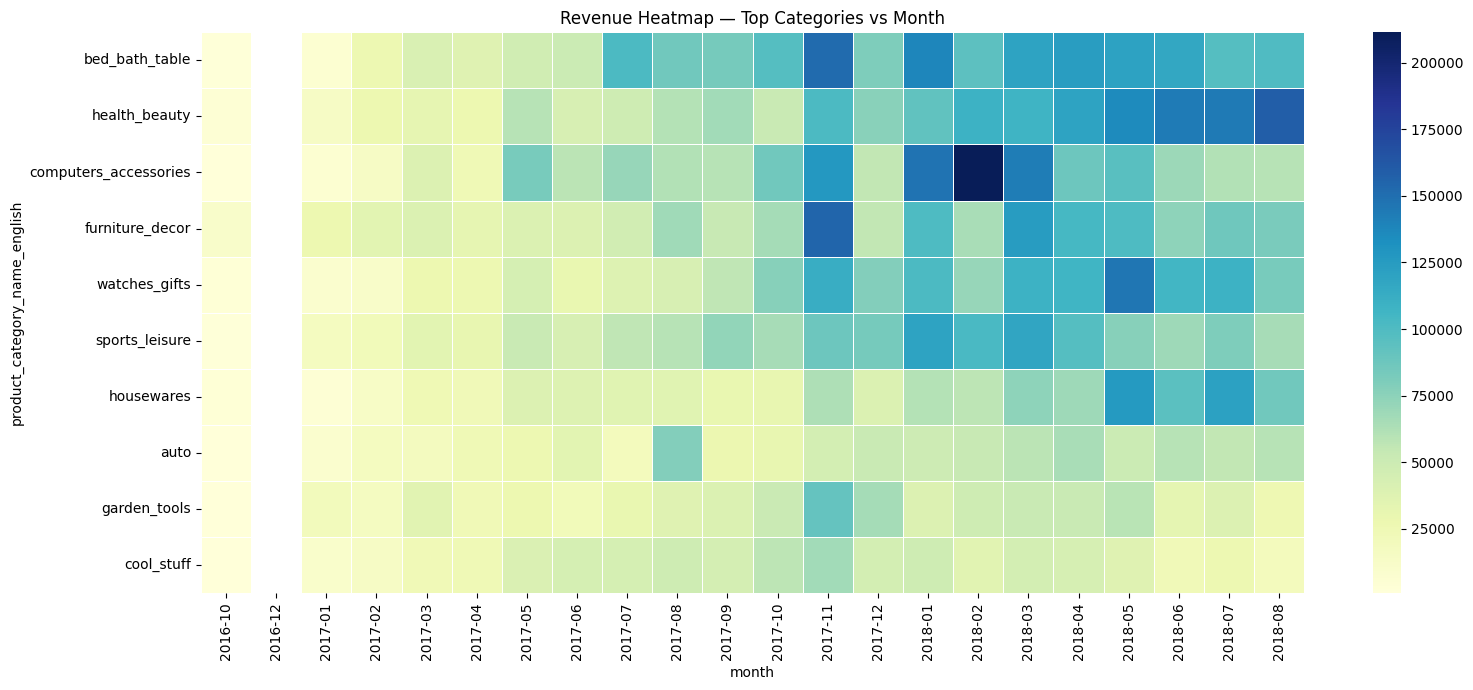

In [28]:
# Chart 6 — Heatmap: Category vs Month
pivot = df.pivot_table(values='payment_value', index='product_category_name_english', columns='month', aggfunc='sum')
pivot_top = pivot.loc[category_revenue.head(10).index]
plt.figure(figsize=(16,7))
sns.heatmap(pivot_top, cmap='YlGnBu', linewidths=0.5)
plt.title('Revenue Heatmap — Top Categories vs Month')
plt.tight_layout()
plt.savefig('chart6_heatmap.png')
plt.show()

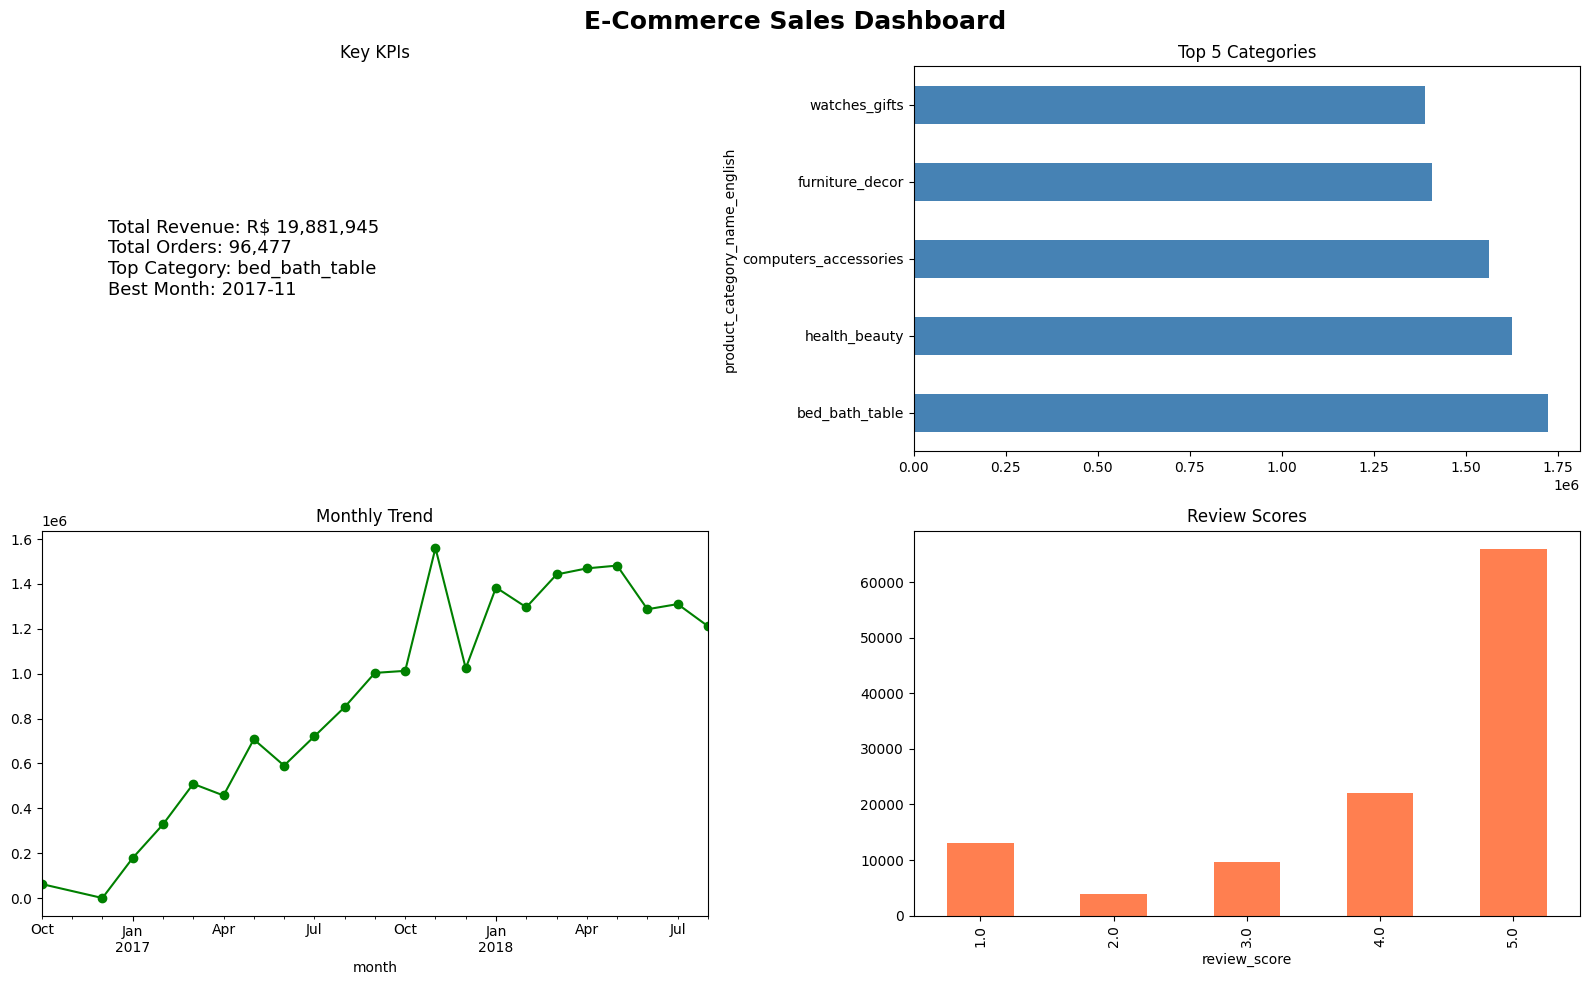

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('E-Commerce Sales Dashboard', fontsize=18, fontweight='bold')

# KPI text box
total_revenue = df['payment_value'].sum()
total_orders = df['order_id'].nunique()
top_category = category_revenue.idxmax()
best_month = monthly_sales.idxmax()

kpi_text = f"""
Total Revenue: R$ {total_revenue:,.0f}
Total Orders: {total_orders:,}
Top Category: {top_category}
Best Month: {best_month}
"""
axes[0,0].text(0.1, 0.5, kpi_text, fontsize=13, verticalalignment='center')
axes[0,0].set_title('Key KPIs')
axes[0,0].axis('off')

# Mini charts inside dashboard
category_revenue.head(5).plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Top 5 Categories')

monthly_sales.plot(ax=axes[1,0], color='green', marker='o')
axes[1,0].set_title('Monthly Trend')

df['review_score'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Review Scores')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150)
plt.show()

# Business Insights Report — E-Commerce Sales Analysis

**Dataset:** Olist Brazilian E-Commerce | **Total Revenue:** R$ 19,881,945 | **Total Orders:** 96,477

---

**Insight 1: Bed, Bath & Table is the top revenue-generating category**
Chart 1 shows that "bed_bath_table" leads all categories with ~R$ 1.75M in revenue,
followed closely by health_beauty (~R$ 1.62M) and computers_accessories (~R$ 1.56M).
The top 3 categories are surprisingly close in revenue, suggesting no single category
dominates the market.
**Recommendation:** Bundle bed/bath products with home decor items and run cross-category
promotions to increase basket size across all three top categories.

---

**Insight 2: November 2017 was the peak sales month — Black Friday effect**
Chart 2 clearly shows a sharp spike in November 2017 (~R$ 1.55M), which is ~55% higher
than the surrounding months. Sales grew steadily from Oct 2016 to Nov 2017, then
stabilized at ~R$ 1.2–1.5M through 2018.
**Recommendation:** Plan inventory build-up 2 months before November every year.
Introduce early Black Friday deals in late October to capture demand earlier.

---

**Insight 3: São Paulo dominates — but over-reliance is a risk**
Chart 3 shows SP (São Paulo) accounts for ~R$ 7.5M revenue, nearly 3x more than
RJ (Rio de Janeiro) at ~R$ 2.7M. The remaining states contribute very little.
**Recommendation:** While SP must remain the priority, targeted marketing campaigns
in MG (Minas Gerais) and RS could unlock significant untapped revenue, as these
states show moderate existing demand.

---

**Insight 4: Most customers spend under R$ 500 per order**
Chart 4 (histogram) shows a heavy right skew — the vast majority of orders fall
below R$ 500, with very few high-value outliers extending to R$ 14,000+.
This indicates a largely budget-conscious customer base with occasional premium buyers.
**Recommendation:** Introduce bundle deals and "buy more save more" offers to push
average order value from the R$ 100–300 range toward R$ 400–500. Target high-value
outlier customers with a VIP loyalty program.

---

**Insight 5: 57.5% customers gave 5 stars — but 11.4% gave only 1 star**
Chart 5 shows customer satisfaction is polarized. While 57.5% are highly satisfied,
11.4% gave the worst possible rating (1 star), which is a significant churn risk.
The heatmap (Chart 6) shows computers_accessories had its highest revenue spike in
Feb 2018 — a category prone to quality complaints.
**Recommendation:** Investigate 1-star reviews specifically in electronics and
furniture categories. Implement a post-delivery follow-up system within 48 hours
of delivery to catch dissatisfied customers before they leave negative reviews.

## Most Surprising Finding

The most unexpected finding was that "bed_bath_table" — a seemingly ordinary 
household category — outperformed tech products like computers and accessories 
in total revenue. I initially expected electronics to dominate an e-commerce 
platform. Additionally, the dramatic November 2017 spike (~55% above average) 
confirmed Black Friday's massive impact even in the Brazilian market, which I 
had underestimated.